## **1. Import Library**

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## **2. Data Loading**

In [ ]:
df = pd.read_csv('../diabetes_raw.csv')

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nSample Data:")
df.head()

Shape: (768, 9)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Sample Data:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## **3. Exploratory Data Analysis (EDA)**

### Statistik Deskriptif

In [21]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Cek Missing Values

In [22]:
print("Missing values per kolom:")
print(df.isnull().sum())

Missing values per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Distribusi Targe

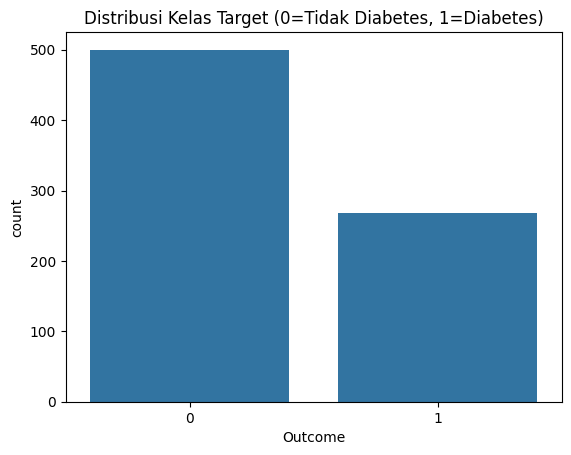

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [23]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribusi Kelas Target (0=Tidak Diabetes, 1=Diabetes)')
plt.show()

print(df['Outcome'].value_counts(normalize=True) * 100)

### Distribusi Fitur

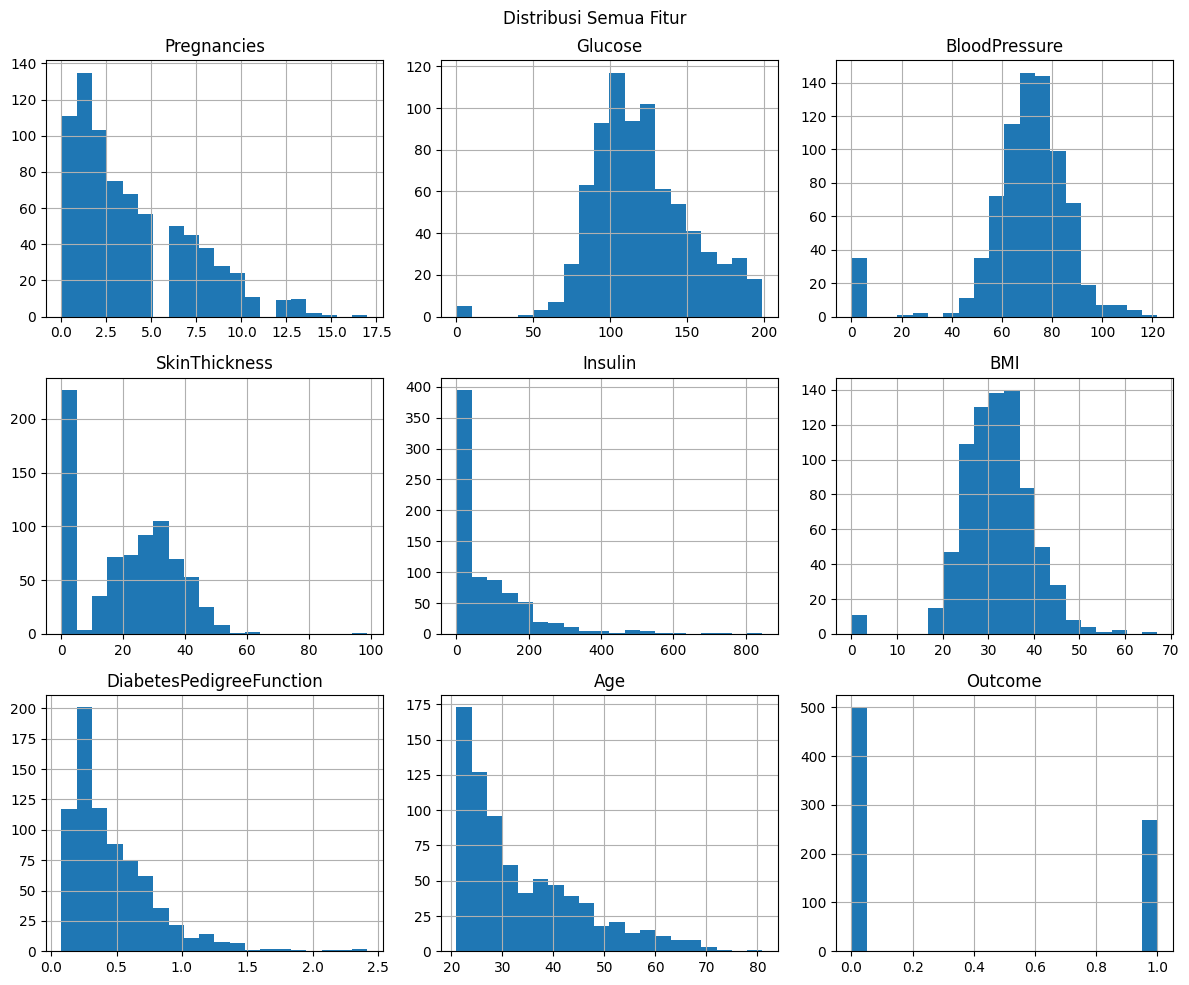

In [24]:
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Distribusi Semua Fitur')
plt.tight_layout()
plt.show()

### Korelasi Antar Fitur

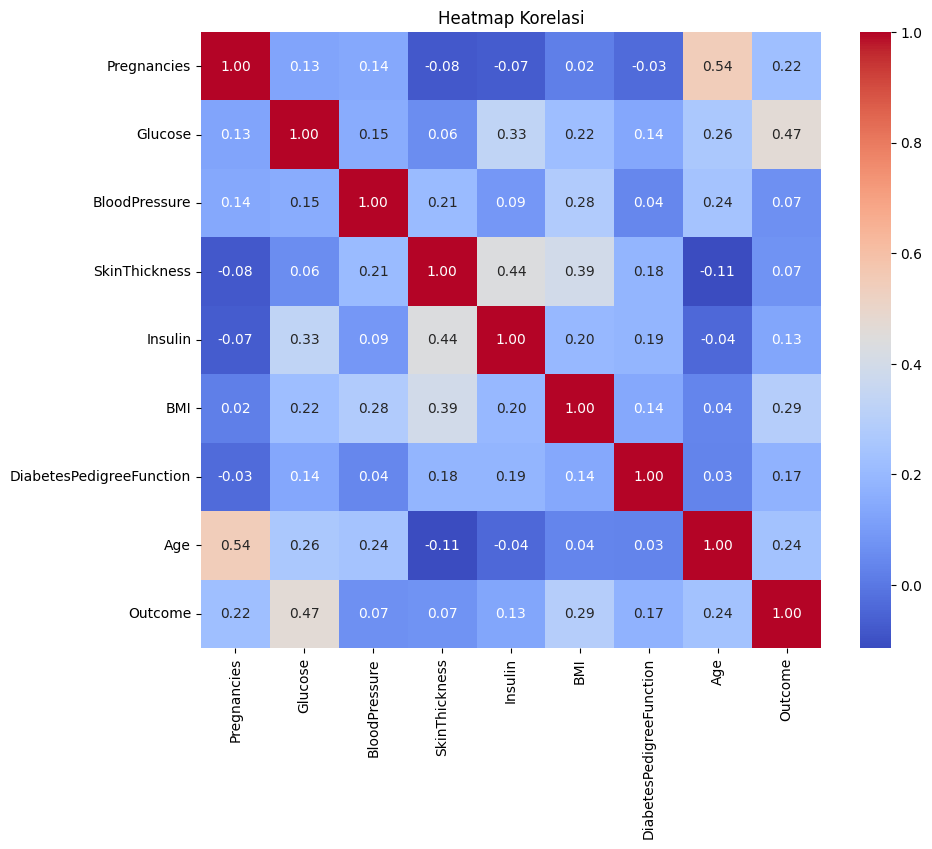

In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

### Deteksi Outlier dengan Boxplot

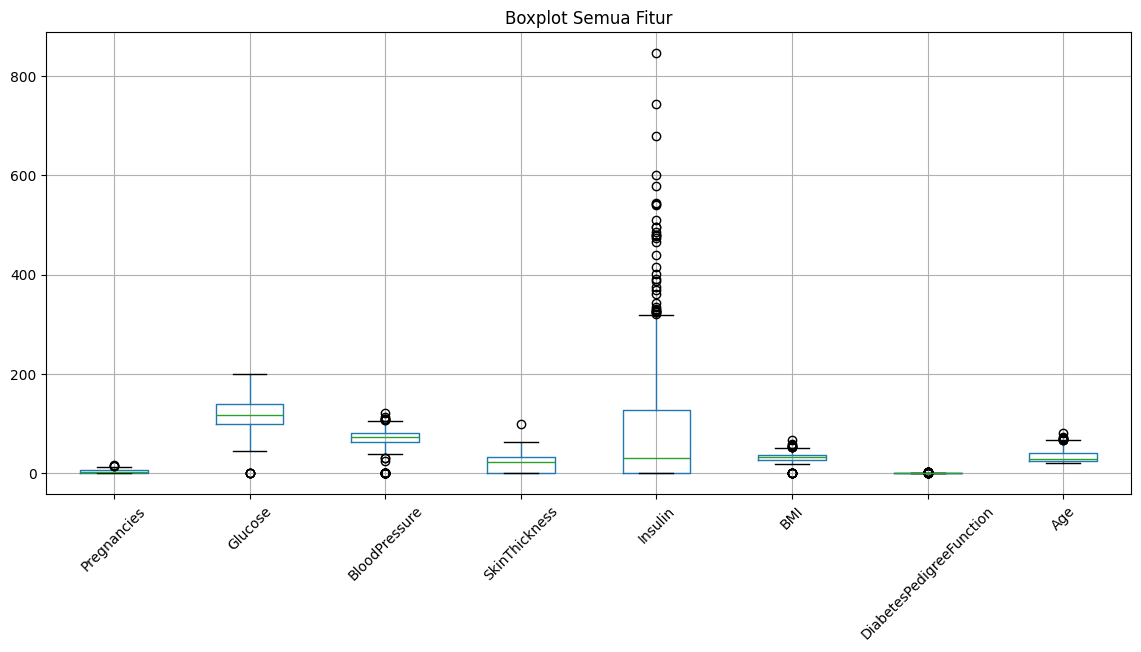

In [26]:
plt.figure(figsize=(14, 6))
df.drop('Outcome', axis=1).boxplot()
plt.title('Boxplot Semua Fitur')
plt.xticks(rotation=45)
plt.show()

## **4. Preprocessing**

### Tangani Zero Values

In [27]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

print("Missing values setelah penanganan:")
print(df.isnull().sum())

Missing values setelah penanganan:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Pisahkan Fitur dan Target

In [28]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

### Split Data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (614, 8)
Test size: (154, 8)


### Scaling

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan sebagai DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

### Simpan Dataset

In [31]:
output_dir = 'diabetes_preprocessing'
os.makedirs(output_dir, exist_ok=True)

X_train_scaled.to_csv(f'{output_dir}/X_train.csv', index=False)
X_test_scaled.to_csv(f'{output_dir}/X_test.csv', index=False)
y_train.to_csv(f'{output_dir}/y_train.csv', index=False)
y_test.to_csv(f'{output_dir}/y_test.csv', index=False)

print("Dataset preprocessed berhasil disimpan!")

Dataset preprocessed berhasil disimpan!
